# 1. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split , KFold , cross_val_score ,StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import lightgbm as lgb
import torch

import warnings
warnings.filterwarnings('ignore')


# 2. Base configration

In [39]:
BATCH_SIZE =62
LEARNING_RATE =0.01
EPOCHS = 100

DATA_PATH ="Telco_Customer_Churn.xlsx"
print(f"  Epochs: {EPOCHS}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Learning Rate: {LEARNING_RATE}")

  Epochs: 100
  Batch Size: 62
  Learning Rate: 0.01


# 3. Load Data

In [40]:
def load_data(data_path= DATA_PATH):
    """
    Load Data from excel file

    Returns:
        x_train, x_test, y_train, y_test: feature matrices , training and test target
    """
    print("\n" + "="* 50)
    print("LOADING DATA")
    print("=" *50 )
    
    data_df = pd.read_excel(data_path)

    #separate feature and target for all data and drop some colume to avoide data Leakage
    X= data_df.drop(
        columns=[
            'Churn Label',
            'Churn Score',
            'Churn Reason',
            'Churn Value',
            'CustomerID', 
            'Count'
        ]
    )

    Y= data_df['Churn Value']

    # seperate  feature and target for train and test data

    X_train, X_test ,Y_train ,Y_test = train_test_split(
        X, 
        Y, 
        test_size=0.2, 
        random_state=42, 
        stratify=Y
    )
    # Convert Total Charges from string to numeric
    X_train['Total Charges'] = pd.to_numeric(
        X_train['Total Charges'], errors='coerce'
    )
    
    X_test['Total Charges'] = pd.to_numeric(
        X_test['Total Charges'], errors='coerce'
    )
     
    print(f"Training data: {X_train.shape[0] } samples, {X_train.shape[1]} features")
    print(f"Test data: {X_test.shape[0]} samples, {X_test.shape[1]} features")
    print(f"Missing values in training: {X_train.isnull().sum().sum()}")
    print(f"Class distribution in training: {np.bincount(Y_train)}")

    return  X_train, X_test, Y_train, Y_test 

# load the data
X_train, X_test, Y_train, Y_test= load_data()



LOADING DATA
Training data: 5634 samples, 27 features
Test data: 1409 samples, 27 features
Missing values in training: 8
Class distribution in training: [4139 1495]


# 4.Handle Missing Value

We use **median imputation** to handle missing values:
- More robust to outliers than mean imputation
- Calculate imputation values from training data only
- Apply the same values to test data (no data leakage)

In [42]:

def handle_missing_values(X_train, X_test):
    """
    Impute missing value using training statistics
    
    Args:
        X_train: Training feature matrix
        X_test: Test feature matrix
        stratige: 'median'
    """
    print("\n" +"="*50)
    print("HANDLING MISSING VALUES")
    print("="* 50)

    
    numeric_columns = X_train.select_dtypes(
        include=['int64', 'float64']
    ).columns

    imputer = SimpleImputer(strategy='median')

    X_train[numeric_columns] = imputer.fit_transform(
        X_train[numeric_columns]
    )

    X_test[numeric_columns] = imputer.transform(
        X_test[numeric_columns]
    )

    print(f"Missing values after imputation:")
    print(f"  Training: {X_train.isna().sum().sum()}")
    print(f"  Test: {X_test.isna().sum().sum()}")
    return X_train, X_test

# Apply Missing Value 

X_train, X_test = handle_missing_values(X_train, X_test)


HANDLING MISSING VALUES
Missing values after imputation:
  Training: 0
  Test: 0


# 5. Feature Engineering 

make new feature to improve the performance

In [43]:
def create_features(X_train, X_test):
    """
    perform feature engineering to boost performance

    Args:
       X_train: Training feature matrix
       X_test: Test feature matrix

    Returns:
        X_train , X_test    
    """
    print("\n" + "="*50)
    print("GENRATE NEW FEATURE ")
    print("="*50)

    X_train = X_train.copy()
    X_test = X_test.copy()

    
    X_train['Avg_Monthly_Spend'] = (
        X_train['Total Charges'] /
        (X_train['Tenure Months'] + 1)
    )

    X_train['Is_New_Customer'] = (
        X_train['Tenure Months'] < 12
    ).astype(int)

    X_train['Is_Loyal_Customer'] = (
        X_train['Tenure Months'] >= 48
    ).astype(int)

    X_train['CLTV_per_Month'] = (
        X_train['CLTV'] /
        (X_train['Tenure Months'] + 1)
    )

    X_test['Avg_Monthly_Spend'] = (
        X_test['Total Charges'] /
        (X_test['Tenure Months'] + 1)
    )

    X_test['Is_New_Customer'] = (
        X_test['Tenure Months'] < 12
    ).astype(int)

    X_test['Is_Loyal_Customer'] = (
        X_test['Tenure Months'] >= 48
    ).astype(int)

    X_test['CLTV_per_Month'] = (
        X_test['CLTV'] /
        (X_test['Tenure Months'] + 1)
    )

    return X_train, X_test

#Apply feature Engineering
X_train, X_test = create_features( X_train ,X_test)
print (f"Shape of Training :{X_train.shape}")
print (f"shape of Testing :{X_test.shape}")


GENRATE NEW FEATURE 
Shape of Training :(5634, 31)
shape of Testing :(1409, 31)


# 6. Detect and Remove outlier

we use the **IQR(Inter quartile Range) Method** to detect outliers
- calculate Q1(25th percentile) and Q3(75th percentile).
- IQR = Q3 - Q1
- Outlier are value < Q1- 1.5*IQR OR  >Q3 +1.5*IQR .

In [44]:
import numpy as np 

def cap_outlier_percentile(X_train, X_test, Lower_percentile=5, Upper_percentile=95): 
    """
    cap outliers in both Train and Test sets using statistices dervied only from the Trains set to prevent data leaakage.
    
    Args:
        x_train: Training feature metrices
        x_test: Test feature matrices 
        lower_percentile: Lower Bound percentile(defult 5)
        upper_percentile: upper Bound percentile(defult 95)
    
    Return:
        x_train_capped, x_test_capped :Transformer fature matrices    
    """
    print("\n" + "="*50)
    print("CAPPING OUTLIERS")
    print(f"Bound derived from train:{Lower_percentile}th - {Upper_percentile}th percentiles")
    print("="*50)

    X_train_capped =X_train.copy()
    X_test_capped= X_test.copy()
    n_features= X_train.shape[1]

    total_capped_train = 0
    total_capped_test =0 

    numeric_columns = X_train.select_dtypes(include=np.number).columns

    for col in numeric_columns:
        train_feature_data= X_train[col]

        lower_bound = np.percentile(train_feature_data, Lower_percentile)
        upper_bound = np.percentile(train_feature_data, Upper_percentile)
   
        outlier_train = (X_train_capped[col] < lower_bound ) | \
                        (X_train_capped[col] > upper_bound)
        total_capped_train += np.sum(outlier_train)

        X_train_capped[col]= np.clip(
            X_train_capped[col], lower_bound, upper_bound
        )

        outlier_test= (X_test_capped[col] < lower_bound) |\
                      (X_test_capped[col] > upper_bound)
        total_capped_test += np.sum(outlier_test)

        X_test_capped[col] = np.clip(
            X_test_capped[col], lower_bound, upper_bound
        )              

    return  X_train_capped ,X_test_capped

#Apply capping 
X_train , X_test = cap_outlier_percentile(X_train , X_test , Lower_percentile=5, Upper_percentile=95)

print (f"Shape of Training :{X_train.shape}")
print (f"shape of Testing :{X_test.shape}")



CAPPING OUTLIERS
Bound derived from train:5th - 95th percentiles
Shape of Training :(5634, 31)
shape of Testing :(1409, 31)


# 7. Detect High Cardinality 

some feature are high cardinality 

In [45]:
def check_high_cardinality(X_train, threshold_ratio=0.9):
    """
    find features with high cordinality.

    Args: 
       x_train: feature matrix
       threshold_ratio: percentage of unique value relative to dataset size

    Return:
        suspicions_features: list    
    """
    print("\n" +"="*50 )
    print("CHICKING HIGH CARDINALITY FEATURES")
    print("="*50)

    n_row= len(X_train)
    suspicious_features= []
    for col in X_train.columns:
        unique_count=X_train[col].nunique()
        unique_ratio= unique_count/ n_row

        print(f"{col:<25}" f"unique ={unique_count:<6}" f"Ratio ={unique_ratio:.2%}")

        if unique_ratio >= threshold_ratio:
            suspicious_features.append(col)

    print("\npotential ID_Like features:")
    print(suspicious_features)

    return suspicious_features 

#Chick cardinality      
suspect_cols = check_high_cardinality(X_train, threshold_ratio=0.9)


CHICKING HIGH CARDINALITY FEATURES
Country                  unique =1     Ratio =0.02%
State                    unique =1     Ratio =0.02%
City                     unique =1128  Ratio =20.02%
Zip Code                 unique =1498  Ratio =26.59%
Lat Long                 unique =1650  Ratio =29.29%
Latitude                 unique =1495  Ratio =26.54%
Longitude                unique =1491  Ratio =26.46%
Gender                   unique =2     Ratio =0.04%
Senior Citizen           unique =2     Ratio =0.04%
Partner                  unique =2     Ratio =0.04%
Dependents               unique =2     Ratio =0.04%
Tenure Months            unique =72    Ratio =1.28%
Phone Service            unique =2     Ratio =0.04%
Multiple Lines           unique =3     Ratio =0.05%
Internet Service         unique =3     Ratio =0.05%
Online Security          unique =3     Ratio =0.05%
Online Backup            unique =3     Ratio =0.05%
Device Protection        unique =3     Ratio =0.05%
Tech Support           

# 8.Drop feature (fixed feature)

some feature are fixed and not necessary for model 

In [46]:
def drop_feature(X_train,X_test, colum_to_drop):
    """
    Drop selected feature from Train and Test set

    Args:
       X_train:Train featutre matrix 
       X_test :Test feature matrix 
       columns_to_drop: List of columns to remove

    Returns:
         x_train_dropped, X_test_dropped
    """
    print("\n" +"="*50)
    print("DROPPING FEATURE")
    print("="*50)

    print(f"colum removed :{colum_to_drop}")

    X_train_dropped= X_train.drop(columns= colum_to_drop)
    X_test_dropped= X_test.drop(columns=colum_to_drop)

    print(f"Train shape: {X_train.shape} -> {X_train_dropped.shape}")
    print(f"Test shape: {X_test.shape} -> {X_test_dropped.shape}")

    return X_train_dropped , X_test_dropped

# remove columns
column_to_drop=['Country', 'State','Lat Long','City', 'Zip Code', 'Latitude', 'Longitude']

X_train , X_test=drop_feature(X_train, X_test, column_to_drop)


DROPPING FEATURE
colum removed :['Country', 'State', 'Lat Long', 'City', 'Zip Code', 'Latitude', 'Longitude']
Train shape: (5634, 31) -> (5634, 24)
Test shape: (1409, 31) -> (1409, 24)


# 9.Feature Encoding 

Applied One-Hot Encoding to transform categorical variables into numerical binary features.

In [47]:
def apply_one_hot_encoding(X_train, X_test):
    """
    Apply one-hot encoding to categorical features.

    Args:
       X_train:Train Feature matrix.
       X_test: Test Feature matrix.

    Returns:
        X_train_encoded, X_test_encoded
    """
    print("\n" +"="*50)
    print("APPLYING ONE-HOT ENCODING")
    print("="*50)

    # Convert 'Total Charges' to numeric to avoid generating thousands of unnecessary dummy variables during One-Hot Encoding
    
    X_train['Total Charges'] = pd.to_numeric(
    X_train['Total Charges'],
    errors='coerce'
    )

    X_test['Total Charges'] = pd.to_numeric(
    X_test['Total Charges'],
    errors='coerce'
    )

    # drop some colume to avoid generating thousands of unnecessary dummy variables during One-Hot Encoding

    columns_to_drop = [
    'Country',
    'State',
    'Lat Long',
    'City',
    'Zip Code'
    ]
    X_train = X_train.drop(columns=columns_to_drop, errors='ignore')
    X_test = X_test.drop(columns=columns_to_drop, errors='ignore')
    
    categarical_colum=X_train.select_dtypes(include='object').columns
    print(categarical_colum)

    X_train_encoded=pd.get_dummies(X_train, drop_first=True)
    X_test_encoded= pd.get_dummies(X_test, drop_first=True)

    X_train_encoded, X_test_encoded=X_train_encoded.align(
        X_test_encoded,
        join='left',
        axis=1,
        fill_value=0                                                   
    )

    print(f"Train Shape: {X_train.shape} -> Train_Encoded Shape{X_train_encoded.shape}")
    print(f"Test Shape: {X_test.shape} -> Test_Encoded Shape{X_test_encoded.shape}")

    return X_train_encoded, X_test_encoded

# make feature encding
X_train, X_test = apply_one_hot_encoding(X_train, X_test)
print("\n")
print(X_test.dtypes.unique())


APPLYING ONE-HOT ENCODING
Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method'],
      dtype='str')
Train Shape: (5634, 24) -> Train_Encoded Shape(5634, 35)
Test Shape: (1409, 24) -> Test_Encoded Shape(1409, 35)


[dtype('float64') dtype('int64') dtype('bool')]


C:\Users\Shreen\AppData\Local\Temp\ipykernel_23892\4003922031.py:40: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categarical_colum=X_train.select_dtypes(include='object').columns


# 10.Chick Feature Correlation 

chick for highly correlated Features

In [48]:
def check_correlation(X, threshold=0.8):
    """
    check for highly correlated features.

    Args:
       X:Feature Matrices
       threshold:correlation threshold

    Returns:
        corr_metrix: correlationmatrix   
    """
    print("\n" +"="*50)
    print("CHEICKING FEATURE CORRELATION")
    print("="*50)

    #calculate correlation matrix
    corr_matrix=X.corr()

    #find high correlation (excluding diagnal)
    high_corr_pairs=[]
    n_features=X.shape[1]

    for i in range(n_features):
        for j in range(i+1, n_features):
            corr = corr_matrix.iloc[i, j]
            if abs(corr_matrix.iloc[i,j])> threshold:
                high_corr_pairs.append((
                    corr_matrix.columns[i],
                    corr_matrix.columns[j],
                    corr
                ))

    if len(high_corr_pairs)==0:
        print(f"No High Correlation found (threshold ={threshold})")     
        print(f"No Significant multicpllinearty detect")
    else:
        print(f":Found {len(high_corr_pairs)} Feature pair with correlation > {threshold}")  
        for feat1, feat2, corr in high_corr_pairs[:10]:
            print(f"{feat1} <-> {feat2} :{corr:.3f}")
    return corr_matrix

# check correlation 
corr_matrix=check_correlation(X_train, threshold=0.8)


CHEICKING FEATURE CORRELATION
:Found 25 Feature pair with correlation > 0.8
Tenure Months <-> Total Charges :0.834
Tenure Months <-> Is_Loyal_Customer :0.858
Monthly Charges <-> Avg_Monthly_Spend :0.953
Phone Service_Yes <-> Multiple Lines_No phone service :-1.000
Internet Service_No <-> Online Security_No internet service :1.000
Internet Service_No <-> Online Backup_No internet service :1.000
Internet Service_No <-> Device Protection_No internet service :1.000
Internet Service_No <-> Tech Support_No internet service :1.000
Internet Service_No <-> Streaming TV_No internet service :1.000
Internet Service_No <-> Streaming Movies_No internet service :1.000


# 11.Feature Normalization (z-score)
Apply z-score normalization to standardize feature calculate statistics from training data only to avoid data leakage.

In [49]:
def apply_zscore(X_train,X_test):
    """
    Apply Z-score normalizationز
    Args:
       X_train:Training feature matrix
       X_test: Test feature matrix 
    Returns:
        X_train_scaled, X_test_scaled :Normalization feature matrix. 
    """
    print("\n" +"="*50)
    print("APPLYING Z-SCORE NORMALIZATION")
    print("=" *50)

    mean= np.mean(X_train, axis=0)
    std= np.std(X_train, axis=0)

    # avoid division by zero
    std[std==0]=1

    #Apply to both train and test
    X_train_scaled = (X_train - mean) / std
    X_test_scaled = (X_test - mean) / std
    print(f"Normalized {X_train.shape[1]} feature")
    print(f"Training data : mean= {np.mean(X_train_scaled):.6f}, std={np.std(X_train_scaled):.6f}")
    print(f"Test data : mean= {np.mean(X_test_scaled):.6f}, std={np.std(X_test_scaled):.6f}")

    return X_train_scaled, X_test_scaled

X_train_scaled , X_test_scaled = apply_zscore(X_train, X_test)



APPLYING Z-SCORE NORMALIZATION
Normalized 35 feature
Training data : mean= -0.000000, std=1.000000
Test data : mean= -0.005688, std=0.996641


# 12.Model Training and Evaluation Function 
Define helper function for model training and evaluation using cross-validation 

In [50]:

def evaluate_model_cv(model, X, Y,model_type='sklearn'):
    
   """
   Evaluate model on training data using AUC-ROC

   Args:
      model: Training model
      x: feature matrix
      y: target vector
      model_type: 'sklearn' or 'pytorch'

   Return:
      auc-score:AUC-ROC score on training data   
   """

   if model_type == 'sklearn':
      y_pred_proba = model.predict_proba(X)[:, 1]
   else:
      model.eval()
      with torch.no_grad():
         X_tensor= torch.FloatTensor(X)
         y_pred_proba= model(X_tensor).numpy().flatten()

   auc_score= roc_auc_score(Y, y_pred_proba)
   return auc_score        
    


# 13.Experiment 1: Logistic Regression (Baseline)

In [51]:
def train_Logistic_regression(X_train, Y_train, penalty='l1', C=1.0):
    """
    Train Logistic Regresion model.

    Args:
        x_train: Training feature 
        y_train: Training target 
        penalty: Regularization type('l1' or 'l2')
        c: Inverse regularization strength

    Returns:
        model: Trained model
    """
    print(f"\n Training Logistic Regression penalty {penalty}, C={C}")

    model= LogisticRegression(
        penalty= penalty,
        C = C,
        solver='liblinear',
        max_iter= 1000,
        random_state=42
    )
    model.fit(X_train, Y_train)

    if penalty =='l1' :
        n_nonzero=np.sum(model.coef_ !=0)
        print(f"L1 regularization selected {n_nonzero} non-zero features")

    print(f"Model Trained Successfully")
    return model

def cross_validation_model(X_train, Y_train ,penalty='l2', C=1.0, n_folds=5):
    """
    perform k-fold cross-validation for Logistic Regression
    """
    model= LogisticRegression(
        penalty= penalty,
        C=C,
        solver= 'liblinear',
        max_iter=1000,
        random_state=42
    )

    cv_scores= cross_val_score(
        model,
        X_train, 
        Y_train,
        cv= n_folds,
        scoring='roc_auc',
        n_jobs=-1
    )
    return np.mean(cv_scores), np.std(cv_scores), cv_scores

print("\n" + "="*50)
print("EXPERIMENT 1:Logistic Regression (Beseline)")
print("="*50)

# cross-validation to estimate performance
lr_cv_mean, lr_cv_std, lr_cv_scores=cross_validation_model(X_train_scaled, Y_train,penalty='l2',C=1.0,n_folds=5)
print(f"\n 5-fold cv AUC-ROC:{lr_cv_mean:.4f} +/- {lr_cv_std:.4f}")
print(f"Individual folds :{lr_cv_scores}")

# Train final model on all Training data
lr_model=train_Logistic_regression(X_train_scaled,Y_train,penalty='l2',C=1.0)
lr_train_auc=evaluate_model_cv(lr_model,X_train_scaled,Y_train, model_type='sklearn')

print(f"\n {'=' *50}")
print(f"Logistic Regression Results:")
print(f"Training AUC_ROC:{lr_train_auc:.4f}")
print(f"CV AUC-ROC:{lr_cv_mean:.4f} +/- {lr_cv_std:.4f}")
print(f"{'='*50}")


EXPERIMENT 1:Logistic Regression (Beseline)

 5-fold cv AUC-ROC:0.8625 +/- 0.0130
Individual folds :[0.8745981  0.87250578 0.86897953 0.85668412 0.83954172]

 Training Logistic Regression penalty l2, C=1.0
Model Trained Successfully

Logistic Regression Results:
Training AUC_ROC:0.8665
CV AUC-ROC:0.8625 +/- 0.0130


c:\Users\Shreen\miniconda3\envs\ai311\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


# 14.Experiment 2:PCA +Logistic Regression

In [52]:
def apply_pca(X_train , X_test, n_components= 30):
    """
    Apply PCA dimensionality reduction 
    """ 
    print(f"\n Applying PCA (n_components ={n_components})")

    pca=PCA(n_components=n_components,random_state=42)
    X_train_pca=pca.fit_transform(X_train)
    X_test_pca=pca.transform(X_test)

    explained_variance=np.sum(pca.explained_variance_ratio_)

    print(f"Reduced from {X_train.shape[1]} to {n_components} principal component")
    print(f"Explained variance :{explained_variance*100:.2f}")

    return X_train_pca , X_test_pca , pca

print("\n" +"="*50)
print("EXPERIMENT 2: PCA + Logistic Regression ")
print("="*50)

X_train_pca, X_test_pca ,pca=apply_pca(X_train_scaled, X_test_scaled, n_components=30)

#cross-validation 
lr_pca_cv_mean, lr_pca_cv_std,_ = cross_validation_model(X_train_pca, Y_train , penalty='l2', C=1.0, n_folds=5)
print(f"\n 5-fold CV AUC_ROC :{lr_pca_cv_mean:.4f} +/- {lr_pca_cv_std:.4f}")

#Training model 
lr_pca_model = train_Logistic_regression(X_train_pca, Y_train , penalty= 'l2',C=1.0)
lr_pca_train_auc= evaluate_model_cv(lr_pca_model, X_train_pca,Y_train, model_type='sklearn')

print(f"\n{'=' *50}")
print(f"PCA +Logistic Regression Result")
print(f"Training AUC-ROC :{lr_pca_train_auc:.4f}")
print(f"CV AUC-ROC :{lr_pca_cv_mean:.4f} +/- {lr_pca_cv_std:.4f}")
print(f"{'=' *50}")


EXPERIMENT 2: PCA + Logistic Regression 

 Applying PCA (n_components =30)
Reduced from 35 to 30 principal component
Explained variance :100.00

 5-fold CV AUC_ROC :0.8625 +/- 0.0130

 Training Logistic Regression penalty l2, C=1.0
Model Trained Successfully

PCA +Logistic Regression Result
Training AUC-ROC :0.8665
CV AUC-ROC :0.8625 +/- 0.0130


c:\Users\Shreen\miniconda3\envs\ai311\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


# 15.Experiment 3: Random Forest

In [53]:
def train_Random_forest(X_train, Y_train, n_estimators=200, max_depth= 10):
    """
    Train Random Forest model.

    Args:
        x_train: Training feature 
        y_train: Training target 

    Returns:
        model: Trained model
    """
    print(f"\n Training Random Forest ")

    model=RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, Y_train)

    print(f"Model Trained Successfully")
    return model

def cross_validation_model(X_train, Y_train , n_estimators=200, max_depth= 10, n_folds=5):
    """
    perform k-fold cross-validation for Random Forest
    """
    model= RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    cv_scores= cross_val_score(
        model,
        X_train, 
        Y_train,
        cv= n_folds,
        scoring='roc_auc',
        n_jobs=-1
    )
    return np.mean(cv_scores), np.std(cv_scores), cv_scores

print("\n" + "="*50)
print("EXPERIMENT 3:Random Forest")
print("="*50)

# cross-validation to estimate performance
lr_cv_mean, lr_cv_std, lr_cv_scores=cross_validation_model(X_train_scaled, Y_train,n_estimators=200,max_depth=10,n_folds=5)
print(f"\n 5-fold cv AUC-ROC:{lr_cv_mean:.4f} +/- {lr_cv_std:.4f}")
print(f"Individual folds :{lr_cv_scores}")

# Train final model on all Training data
lr_model=train_Random_forest(X_train_scaled,Y_train,n_estimators=200,max_depth=10)
lr_train_auc=evaluate_model_cv(lr_model,X_train_scaled,Y_train, model_type='sklearn')

print(f"\n {'=' *50}")
print(f"Random Forest Results:")
print(f"Training AUC_ROC:{lr_train_auc:.4f}")
print(f"CV AUC-ROC:{lr_cv_mean:.4f} +/- {lr_cv_std:.4f}")
print(f"{'='*50}")


EXPERIMENT 3:Random Forest

 5-fold cv AUC-ROC:0.8553 +/- 0.0121
Individual folds :[0.86983988 0.86726286 0.85530674 0.84572569 0.83848621]

 Training Random Forest 
Model Trained Successfully

Random Forest Results:
Training AUC_ROC:0.9268
CV AUC-ROC:0.8553 +/- 0.0121


# 16.Experiment 4: XGBoost Classifier

In [54]:
def train_XG_Classifier(X_train, Y_train, n_estimators=100, max_depth= 3, learning_rate=0.03):
    """
    Train XGBoost Classifier model.

    Args:
        x_train: Training feature 
        y_train: Training target 

    Returns:
        model: Trained model
    """
    print(f"\n Training XGBoost Classifier ")

    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=0.7,
        colsample_bytree=0.7,
        random_state=42,
        eval_metric='logloss'
    )

    model.fit(X_train, Y_train)

    print(f"Model Trained Successfully")
    return model

def cross_validation_model(X_train, Y_train , n_estimators=100, max_depth= 3, learning_rate=0.03,n_folds=5):
    """
    perform k-fold cross-validation for XGBoost 
    """
    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=0.7,
        colsample_bytree=0.7,
        random_state=42,
        eval_metric='logloss'
    )
    

    cv_scores= cross_val_score(
        model,
        X_train, 
        Y_train,
        cv= n_folds,
        scoring='roc_auc',
        n_jobs=-1
    )
    return np.mean(cv_scores), np.std(cv_scores), cv_scores

print("\n" + "="*50)
print("EXPERIMENT 4: XGBoost Clasifier")
print("="*50)

# cross-validation to estimate performance
lr_cv_mean, lr_cv_std, lr_cv_scores=cross_validation_model(X_train_scaled, Y_train,n_estimators=100,max_depth=3,learning_rate=0.03,n_folds=5)
print(f"\n 5-fold cv AUC-ROC:{lr_cv_mean:.4f} +/- {lr_cv_std:.4f}")
print(f"Individual folds :{lr_cv_scores}")

# Train final model on all Training data
lr_model=train_XG_Classifier(X_train_scaled,Y_train,n_estimators=100,max_depth=3, learning_rate=0.03)
lr_train_auc=evaluate_model_cv(lr_model,X_train_scaled,Y_train, model_type='sklearn')

print(f"\n {'=' *50}")
print(f"XGBoost Classifier Results:")
print(f"Training AUC_ROC:{lr_train_auc:.4f}")
print(f"CV AUC-ROC:{lr_cv_mean:.4f} +/- {lr_cv_std:.4f}")
print(f"{'='*50}")


EXPERIMENT 4: XGBoost Clasifier

 5-fold cv AUC-ROC:0.8619 +/- 0.0122
Individual folds :[0.87397    0.8707891  0.86867861 0.85455342 0.84129687]

 Training XGBoost Classifier 
Model Trained Successfully

XGBoost Classifier Results:
Training AUC_ROC:0.8721
CV AUC-ROC:0.8619 +/- 0.0122


# 17.Experiment 5: LightGBM Model


EXPERIMENT: LightGBM
Training AUC-ROC: 0.9003
Test AUC-ROC:     0.8576


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

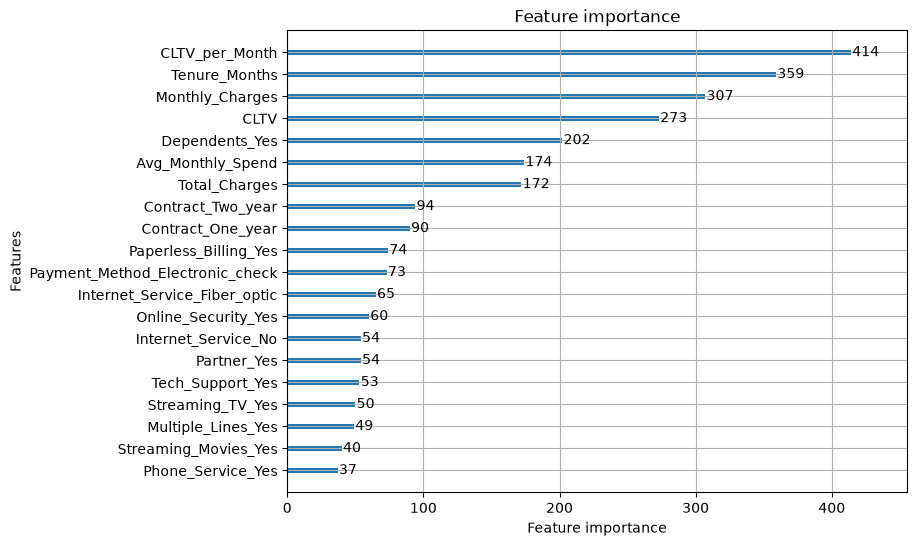

In [67]:

def train_lightgbm(X_train, Y_train, X_test, Y_test):
    """
    Train LightGBM classifier with class imbalance handling
    Args:
       X_train:Training Feature Matrix
       X_test:Test Feature Matrix
       Y_train: Train Target  
       Y_test: Test Target

    Returns:
        Model Traine   
    """
    print("\n" + "="*50)
    print("EXPERIMENT: LightGBM")
    print("="*50)

    model = lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=15,
        max_depth=5,
        min_child_samples=30,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=1.0,           
        reg_lambda=1.0,
        class_weight='balanced',  
        random_state=42,
        verbose=-1 
    )

    
    model.fit(
        X_train, Y_train,
        eval_set=[(X_test, Y_test)],
        eval_metric='auc',
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )


    train_auc = roc_auc_score(Y_train, model.predict_proba(X_train)[:, 1])
    test_auc = roc_auc_score(Y_test, model.predict_proba(X_test)[:, 1])

    print(f"Training AUC-ROC: {train_auc:.4f}")
    print(f"Test AUC-ROC:     {test_auc:.4f}")

    return model

lgb_model = train_lightgbm(X_train, Y_train, X_test, Y_test)

lgb.plot_importance(lgb_model, max_num_features=20, figsize=(8, 6))

# 18.we use Hyperparameter Tuning validation (RandomizedSearchCV)

In [ ]:

param_dist = {
    'num_leaves': [7, 15, 31],
    'max_depth': [3, 5, 7, -1],
    'min_child_samples': [20, 30, 50, 70],
    'learning_rate': [0.01, 0.03, 0.05],
    'n_estimators': [200, 500, 800],
    'reg_alpha': [0, 0.5, 1.0, 2.0],
    'reg_lambda': [0, 0.5, 1.0, 2.0],
    'subsample': [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
}

base_model = lgb.LGBMClassifier(
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

search = RandomizedSearchCV(
    base_model,
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, Y_train)

print("Best params:", search.best_params_)
print("Best CV AUC:", search.best_score_)

best_model = search.best_estimator_
test_auc = roc_auc_score(Y_test, best_model.predict_proba(X_test)[:, 1])
print(f"Test AUC-ROC with best params: {test_auc:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 2.0, 'num_leaves': 7, 'n_estimators': 800, 'min_child_samples': 50, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Best CV AUC: 0.8653866501401148
Test AUC-ROC with best params: 0.8559


# 17. Model for Final test 
Define helper function for evaluate model on test data(Intangible data) 

In [55]:

def test_XG_Classifier(model, X_test, Y_test):
    """
    Evaluate XGBoost Classifier on Test Set.

    Args:
        model: Trained XGBoost model
        X_test: Test features
        Y_test: Test target

    Returns:
        test_auc: Test AUC-ROC score
    """

    print(f"\n Evaluating XGBoost Classifier on Test Set")

    y_pred_proba = model.predict_proba(X_test)[:, 1]

    test_auc = roc_auc_score(Y_test, y_pred_proba)

    print(f"Test Evaluation Completed Successfully")

    return test_auc

# final Result Evaluate

In [68]:
  
lr_model = train_XG_Classifier(
    X_train_scaled,
    Y_train,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.03
)

lr_train_auc = evaluate_model_cv(
    lr_model,
    X_train_scaled,
    Y_train,
    model_type='sklearn'
)

lr_test_auc = test_XG_Classifier(
    lr_model,
    X_test_scaled,
    Y_test
)

print(f"\n {'=' * 50}")
print(f"XGBoost Classifier Results:")
print(f"Training AUC_ROC: {lr_train_auc:.4f}")
print(f"CV AUC-ROC: {lr_cv_mean:.4f} +/- {lr_cv_std:.4f}")
print(f"Test AUC-ROC: {lr_test_auc:.4f}")
print(f"{'=' * 50}")


 Training XGBoost Classifier 
Model Trained Successfully

 Evaluating XGBoost Classifier on Test Set
Test Evaluation Completed Successfully

XGBoost Classifier Results:
Training AUC_ROC: 0.8721
CV AUC-ROC: 0.8619 +/- 0.0122
Test AUC-ROC: 0.8527
